### Entrenando el modelo

Dividimos el train dataset en una relación 90-10, 90% de los datos para entrenamiento y 10% para validacion

In [15]:
import keras
import tensorflow as tf
import matplotlib.pyplot as plt

train_dataset = keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=(256, 256),
    batch_size=32,
    shuffle=True,
    seed=42,
    validation_split=0.3,
    subset="training",
)

validation_dataset = keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=(256, 256),
    batch_size=32,
    shuffle=True,
    seed=42,
    validation_split=0.3,
    subset="validation",
)

print("Splitting validation dataset into test and validation sets...")

val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(2*val_batches // 3)
validation_dataset = validation_dataset.skip(2*val_batches // 3)

print("Final dataset distribution:")

def countElements(dataset):
    count = 0
    for _ in dataset.unbatch():
        count += 1
    return count

# Show how many images we have in each set
print(f"Train dataset: {countElements(train_dataset)} images")
print(f"Validation dataset: {countElements(validation_dataset)} images")
print(f"Test dataset: {countElements(test_dataset)} images")


Found 2159 files belonging to 13 classes.
Using 1512 files for training.
Using 1512 files for training.
Found 2159 files belonging to 13 classes.
Found 2159 files belonging to 13 classes.
Using 647 files for validation.
Using 647 files for validation.
Splitting validation dataset into test and validation sets...
Final dataset distribution:
Splitting validation dataset into test and validation sets...
Final dataset distribution:
Train dataset: 1512 images
Train dataset: 1512 images
Validation dataset: 199 images
Validation dataset: 199 images
Test dataset: 448 images
Test dataset: 448 images


2025-07-05 23:37:36.606339: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


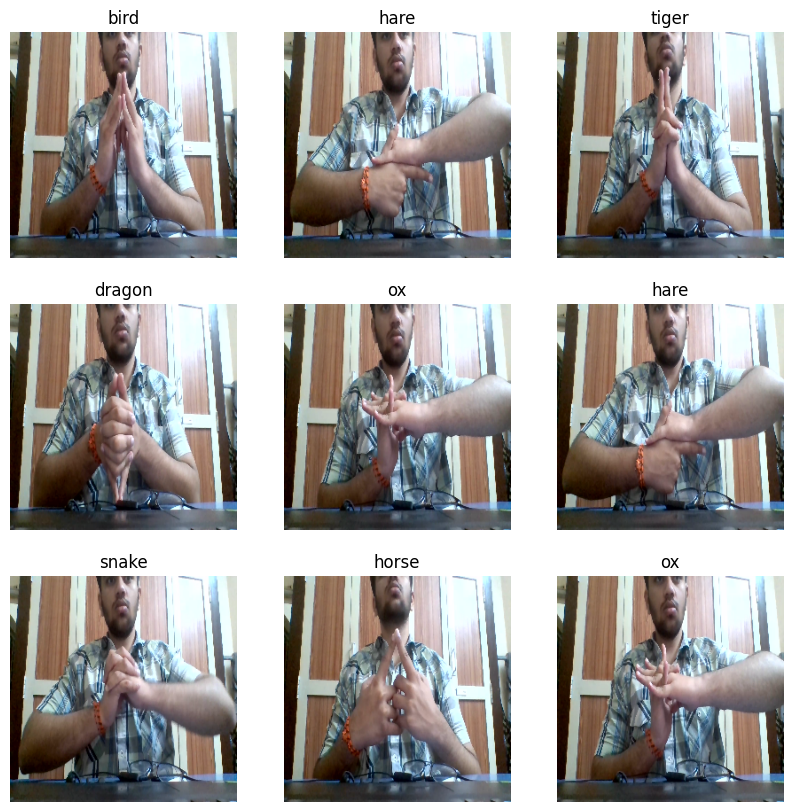

In [16]:
class_names = train_dataset.class_names
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

## Data Augmentation - Análisis para nuestro dataset

*esto lo escribio copilot*

**Situación actual:**
- ~1000 imágenes en entrenamiento
- ~100 imágenes por clase (13 clases)
- Transfer learning con InceptionV3

**¿Necesitamos Data Augmentation?**

**SÍ, es altamente recomendado** por las siguientes razones:

1. **100 imágenes por clase es limitado** para deep learning
2. **Transfer learning ayuda, pero no es suficiente** para generalizar bien
3. **13 clases requieren más variabilidad** para evitar overfitting
4. **Mejora robustez** del modelo ante variaciones de iluminación, ángulos, etc.

**Augmentations recomendadas para nuestro caso:**
- Rotaciones pequeñas (±15°)
- Zoom leve (0.1-0.2)
- Flip horizontal (si es apropiado para las clases)
- Pequeños cambios de brillo y contraste
- **EVITAR**: cambios muy agresivos que cambien la naturaleza de las clases

Empecemos a construir el modelo (por ahora sin augmentation, la agregaremos después si es necesario)

In [17]:
# Usar como base InceptionV3, sin la capa de clasificación final
# Como requisito las imagenes deben tener un tamaño de 299x299x3

base_model = keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3),
)

# Congelar las capas convolucionales
base_model.trainable = False

@keras.saving.register_keras_serializable()
class InceptionPreprocessing(tf.keras.layers.Layer):
    """Capa de preprocesamiento personalizada para InceptionV3 que se puede serializar."""
    
    def __init__(self, **kwargs):
        super(InceptionPreprocessing, self).__init__(**kwargs)
    
    def call(self, inputs):
        return tf.keras.applications.inception_v3.preprocess_input(inputs)
    
    def get_config(self):
        return super(InceptionPreprocessing, self).get_config()

# Crear el modelo usando la capa personalizada (RECOMENDADO)
model = keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(256, 256, 3)),
    InceptionPreprocessing(),  # Capa personalizada en lugar de Lambda
    base_model,  # Base del modelo InceptionV3
    tf.keras.layers.GlobalAveragePooling2D(),  # Pooling global
    
    # Capas adicionales para mejor clasificación
    tf.keras.layers.Dropout(0.3),  # Regularización
    tf.keras.layers.Dense(512, activation='relu'),  # Capa densa intermedia
    tf.keras.layers.BatchNormalization(),  # Normalización
    tf.keras.layers.Dropout(0.2),  # Más regularización
    tf.keras.layers.Dense(256, activation='relu'),  # Segunda capa densa
    tf.keras.layers.Dropout(0.1),  # Regularización final
    tf.keras.layers.Dense(13, activation='softmax')  # Capa de salida con softmax
])

model.summary(show_trainable=False)
model.save("models/untrained.keras")

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_preprocessing_6       │ (None, 256, 256, 3)    │             0 │
│ (InceptionPreprocessing)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1044        │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 13)             │         3,341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,988,589 (87.69 MB)

 Trainable params: 1,184,781 (4.52 MB)

 Non-trainable params: 21,803,808 (83.17 MB)

In [ ]:
# OPCIONAL: Data Augmentation (descomenta si quieres usarlo)
# Recomendado para tu dataset de ~100 imágenes por clase

"""
# Crear data augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),  # ±10% rotación
    tf.keras.layers.RandomZoom(0.1),      # ±10% zoom
    tf.keras.layers.RandomContrast(0.1),  # ±10% contraste
], name="data_augmentation")

# Para aplicarlo, modifica el modelo agregando esta capa después del InputLayer:
# tf.keras.layers.InputLayer(input_shape=(150, 150, 3)),
# data_augmentation,  # <- Agregar esta línea
# tf.keras.layers.Lambda(preprocess),
"""

print("Data augmentation configurado (comentado). Descomenta si quieres usarlo.")

Compilar y entrenar el modelo

In [18]:
base_learning_rate = 0.0001  # Learning rate conservador para transfer learning

# Compilar el modelo con métricas adicionales
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        'accuracy',
    ]
)

# Callbacks para mejorar el entrenamiento
callbacks = [
    # Reducir learning rate cuando val_loss se estanque
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    # Early stopping para evitar overfitting
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    # Guardar el mejor modelo
    tf.keras.callbacks.ModelCheckpoint(
        filepath='models/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Entrenar con más épocas iniciales
initial_epochs = 15

print("Iniciando entrenamiento del modelo...")
history = model.fit(
    train_dataset,
    epochs=initial_epochs,
    validation_data=validation_dataset,
    callbacks=callbacks,
    verbose=1
)

model.save("models/trained.keras")

Iniciando entrenamiento del modelo...
Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2345 - loss: 2.5637
Epoch 1: val_accuracy improved from -inf to 0.74372, saving model to models/best_model.keras

Epoch 1: val_accuracy improved from -inf to 0.74372, saving model to models/best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.2378 - loss: 2.5525 - val_accuracy: 0.7437 - val_loss: 1.2598 - learning_rate: 1.0000e-04
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.2378 - loss: 2.5525 - val_accuracy: 0.7437 - val_loss: 1.2598 - learning_rate: 1.0000e-04
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7568 - loss: 0.9165
Epoch 2: val_accuracy improved from 0.74372 to 0.87437, saving model to models/best_model.keras

Epoch 2: val_accuracy improved from 0.74372 to 0.87437, saving model to models/best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.7574 - loss: 0.9148 - val_accuracy: 0.8744 - val_loss: 0.5631 - le

Graficar curvas de entrenamiento

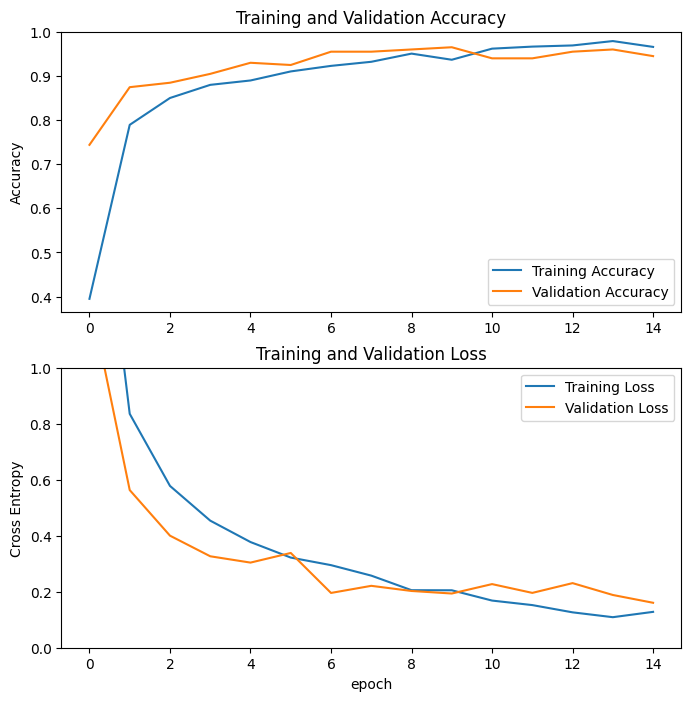

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

Ahora probamos de hacer finetunning

In [21]:
# FINE-TUNING: Descongelar las capas superiores del modelo base
base_model.trainable = True

print("Number of layers in the base model: ", len(base_model.layers))

# Descongelar solo las últimas capas (más específicas)
# InceptionV3 tiene ~311 capas, las últimas son más específicas para tu tarea
fine_tune_at = 249  # Descongelar las últimas ~62 capas

# Mantener congeladas las capas más generales (características básicas)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Capas congeladas: {fine_tune_at}")
print(f"Capas entrenables: {len(base_model.layers) - fine_tune_at}")

# Verificar cuántas capas son entrenables
trainable_count = int(
    sum([1 for layer in base_model.layers if layer.trainable])
)
print(f"Total de capas entrenables en base_model: {trainable_count}")

Number of layers in the base model:  311
Capas congeladas: 249
Capas entrenables: 62
Total de capas entrenables en base_model: 62


Compilar y continuar el entrenamiento

In [22]:
# Compilar para fine-tuning con learning rate más bajo
# IMPORTANTE: Learning rate muy bajo para no destruir características pre-entrenadas
fine_tune_learning_rate = base_learning_rate / 10  # 0.00001

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_learning_rate),
    metrics=['accuracy']
)

# Callbacks específicos para fine-tuning
fine_tune_callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,  # Reducción más agresiva
        patience=2,  # Menos paciencia
        min_lr=1e-8,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,  # Menos épocas de paciencia
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='models/best_finetuned_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Épocas para fine-tuning (menos épocas, más cuidadoso)
fine_tune_epochs = 8
total_epochs = initial_epochs + fine_tune_epochs

print(f"Iniciando Fine-tuning por {fine_tune_epochs} épocas adicionales...")
print(f"Learning rate para fine-tuning: {fine_tune_learning_rate}")

history_fine = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=len(history.epoch),  # Continuar desde donde terminó
    validation_data=validation_dataset,
    callbacks=fine_tune_callbacks,
    verbose=1
)

# Guardar modelo final
model.save("models/final_finetuned_model.keras")

Iniciando Fine-tuning por 8 épocas adicionales...
Learning rate para fine-tuning: 1e-05
Epoch 16/23
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8015 - loss: 0.6387
Epoch 16: val_accuracy improved from -inf to 0.93970, saving model to models/best_finetuned_model.keras

Epoch 16: val_accuracy improved from -inf to 0.93970, saving model to models/best_finetuned_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.8026 - loss: 0.6359 - val_accuracy: 0.9397 - val_loss: 0.2300 - learning_rate: 1.0000e-05
Epoch 17/23
48/48 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.8026 - loss: 0.6359 - val_accuracy: 0.9397 - val_loss: 0.2300 - learning_rate: 1.0000e-05
Epoch 17/23
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9219 - loss: 0.2777
Epoch 17: val_accuracy did not improve from 0.93970
48/48 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9221 - loss: 0.2773 - val_accuracy: 0.9347 - val_loss: 0.2460 - learning_rate: 1.0000e-05
Epoch 18/23

Epoch 17: val_accuracy did

In [23]:


acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()



TypeError: unsupported operand type(s) for +=: 'float' and 'list'

In [24]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

second_test_dataset = keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=(256, 256),
    batch_size=32)

loss, accuracy = model.evaluate(second_test_dataset)
print('Second test accuracy :', accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9599 - loss: 0.1527
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9599 - loss: 0.1527
Test accuracy : 0.9553571343421936
Found 86 files belonging to 13 classes.
Test accuracy : 0.9553571343421936
Found 86 files belonging to 13 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4864 - loss: 1.6708
Second test accuracy : 0.4883720874786377
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4864 - loss: 1.6708
Second test accuracy : 0.4883720874786377


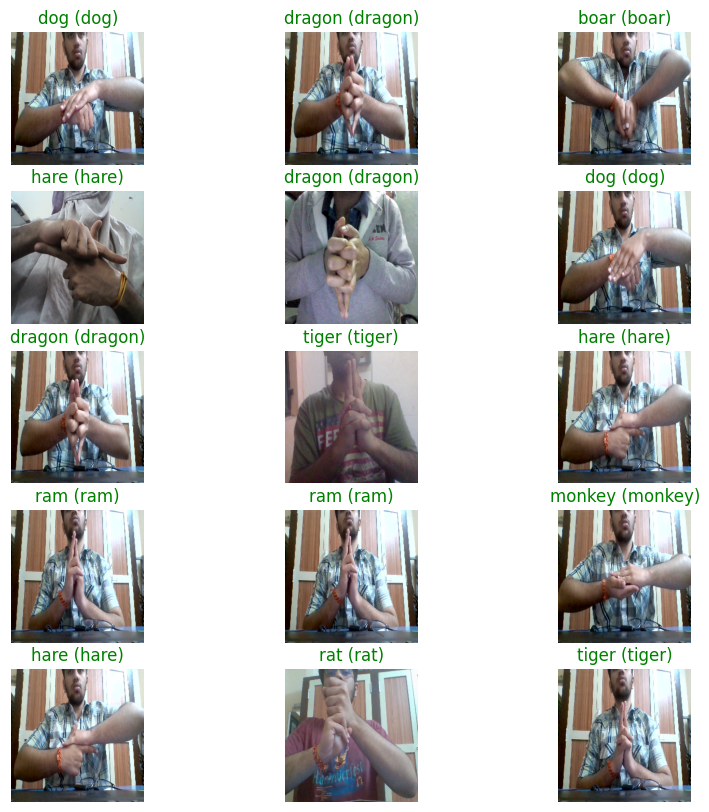

In [25]:
import numpy as np

# Must be divisible by 3
BATCH_SIZE = 15

# Retrieve a random batch of images from the test set
test_dataset = test_dataset.unbatch().batch(BATCH_SIZE)  # Get a batch of
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
prediction = model.predict_on_batch(image_batch)

predictions = []

# Last layer of model is softmax: take the maximum to predict
for arr in prediction:
  predictions.append(np.argmax(arr))

plt.figure(figsize=(10, 10))
for i in range(BATCH_SIZE):
  ax = plt.subplot(BATCH_SIZE // 3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  # The plot title is shows the predicted class and the true class
  plt.title("{} ({})".format(class_names[predictions[i]], class_names[label_batch[i]]),
            color=("green" if predictions[i] == label_batch[i] else "red"))
  plt.axis("off")



Analizar como clasifica cada clase

Clase 0: bird
Cantidad de imágenes: 4
Cantidad de imágenes: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


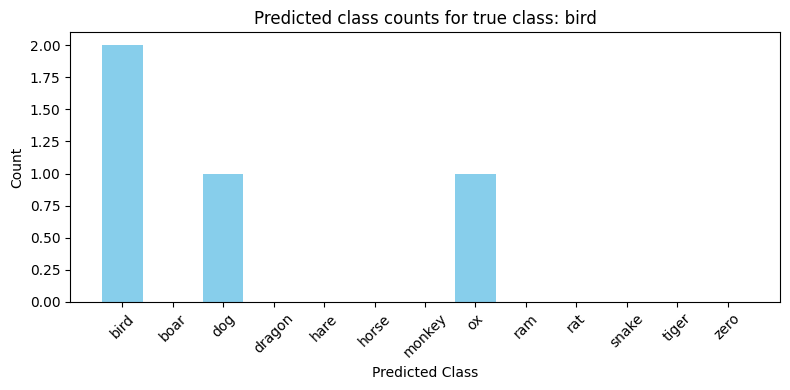

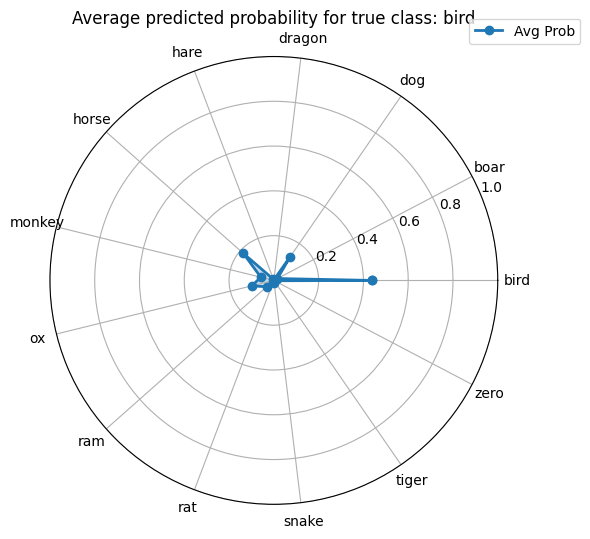

Clase 1: boar
Cantidad de imágenes: 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


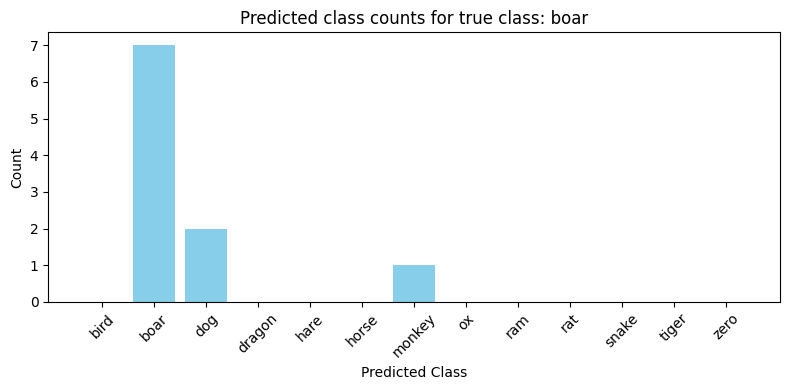

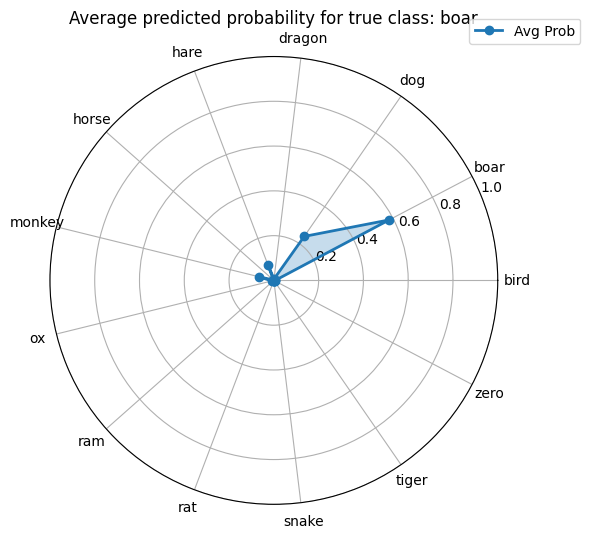

Clase 2: dog
Cantidad de imágenes: 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


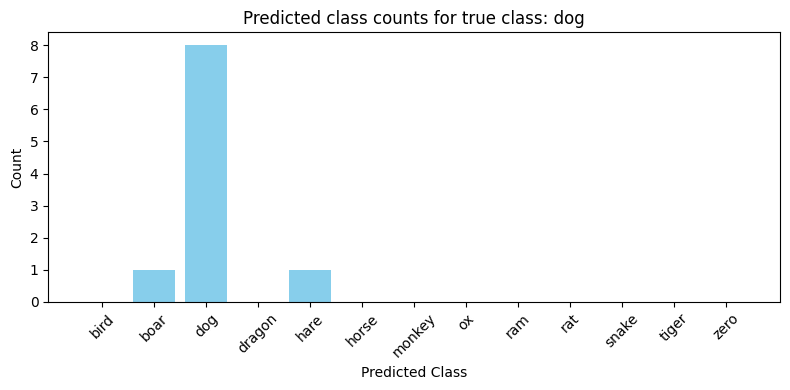

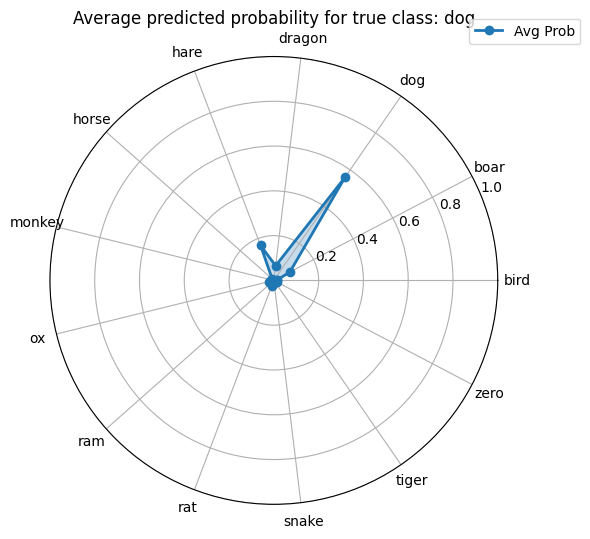

Clase 3: dragon
Cantidad de imágenes: 10
Cantidad de imágenes: 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


2025-07-06 00:50:22.698312: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


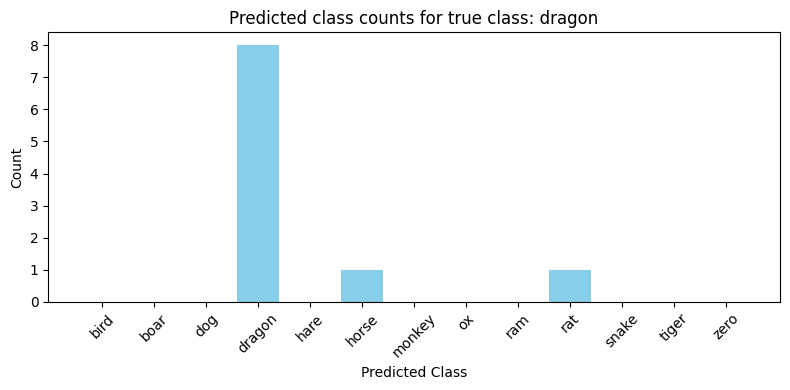

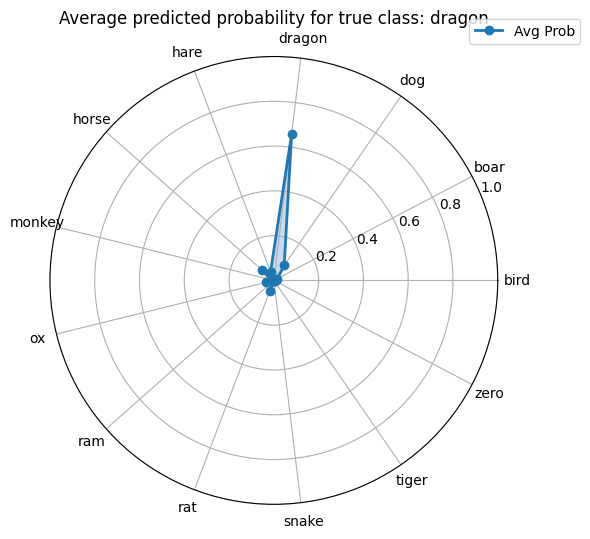

Clase 4: hare
Cantidad de imágenes: 10
Cantidad de imágenes: 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


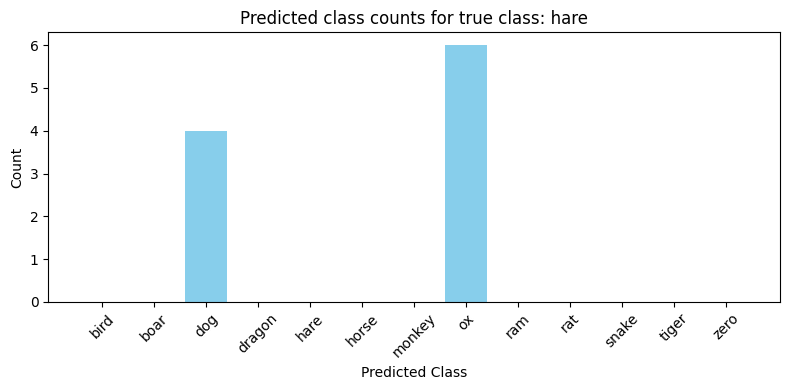

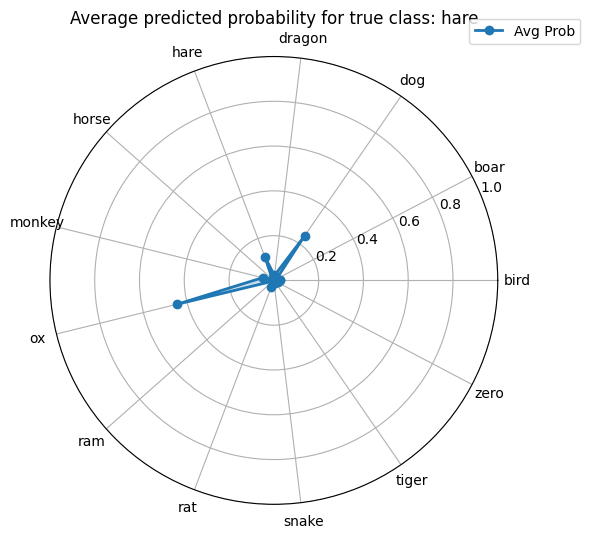

Clase 5: horse
Cantidad de imágenes: 5
Cantidad de imágenes: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


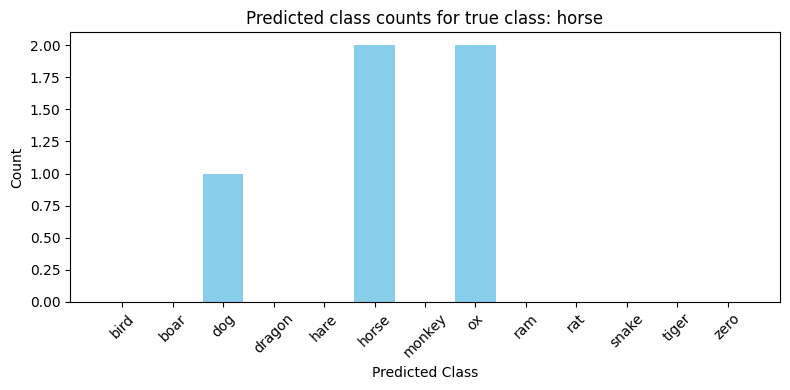

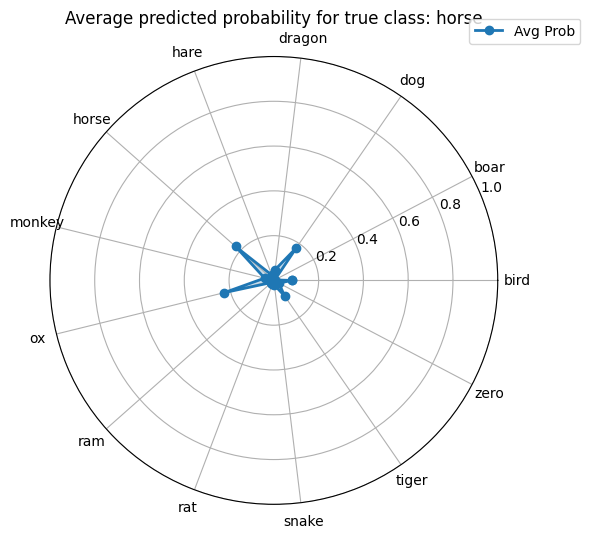

Clase 6: monkey
Cantidad de imágenes: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


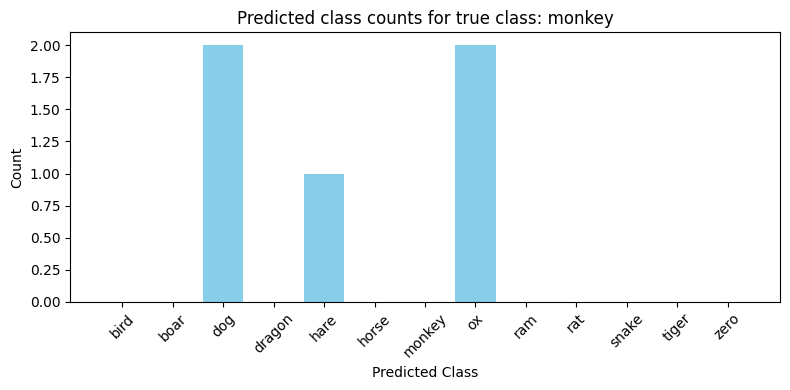

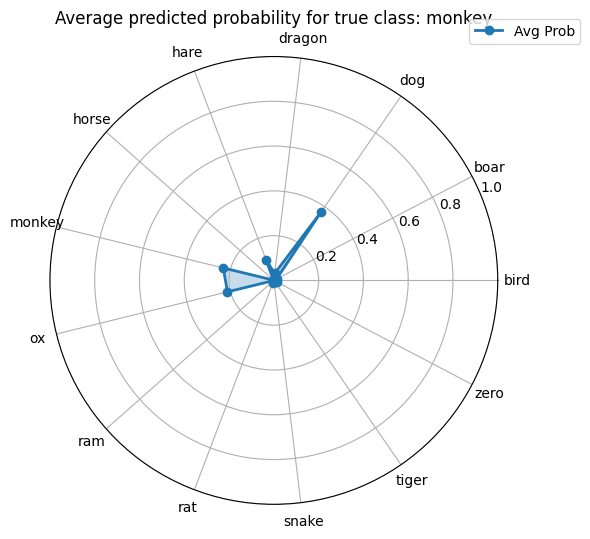

Clase 7: ox
Cantidad de imágenes: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


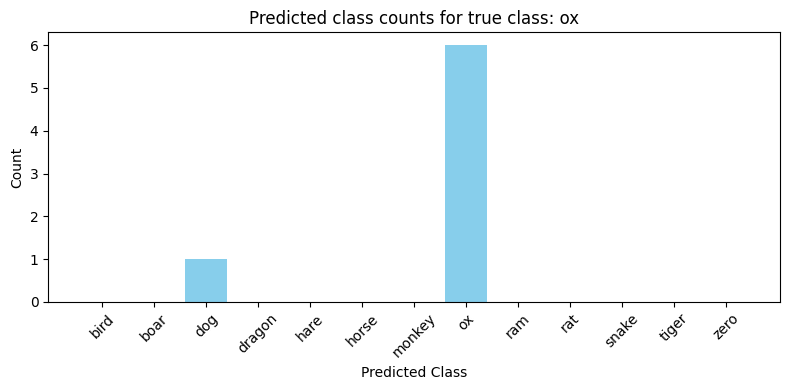

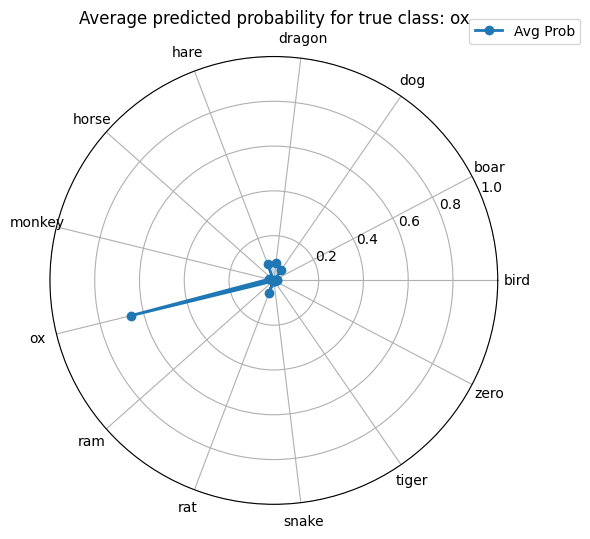

Clase 8: ram
Cantidad de imágenes: 5
Cantidad de imágenes: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


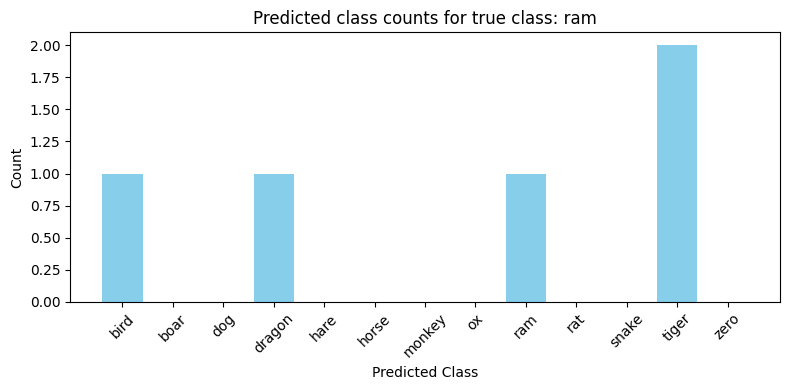

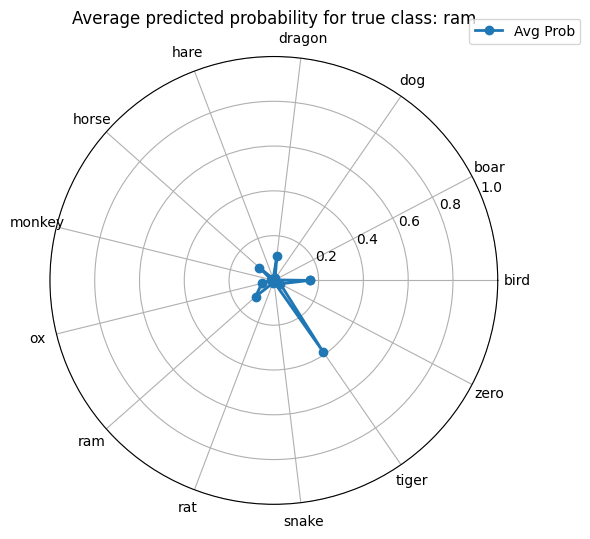

Clase 9: rat
Cantidad de imágenes: 5
Cantidad de imágenes: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


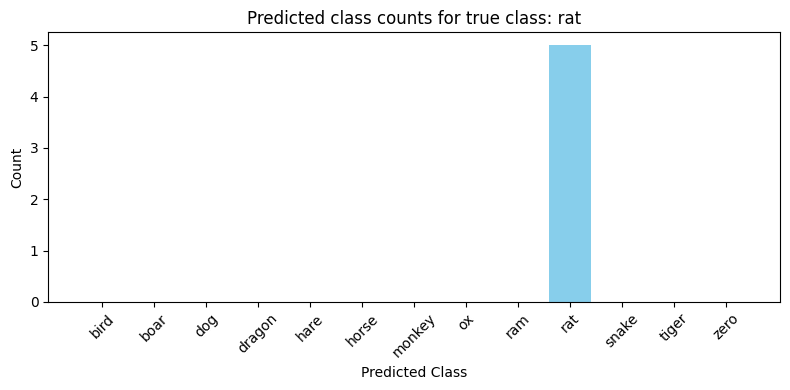

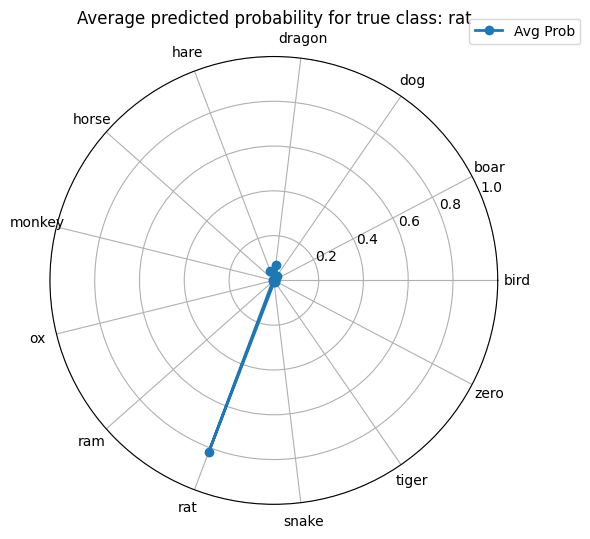

Clase 10: snake
Cantidad de imágenes: 5
Cantidad de imágenes: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


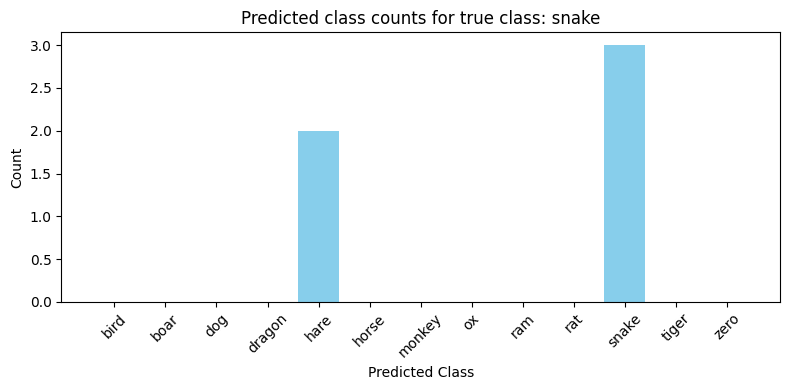

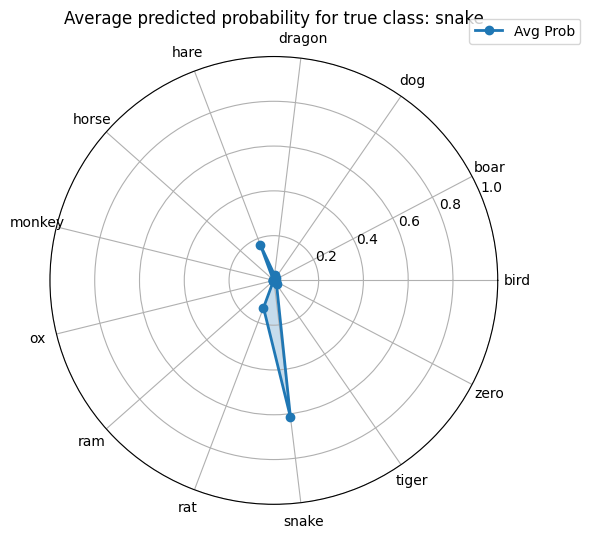

Clase 11: tiger
Cantidad de imágenes: 5
Cantidad de imágenes: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


2025-07-06 00:50:40.334828: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


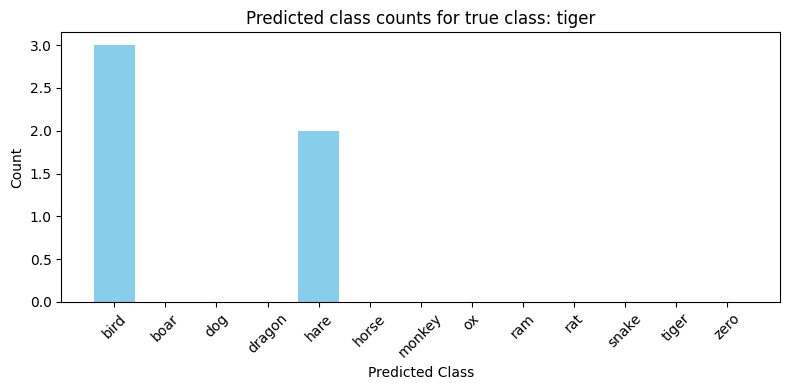

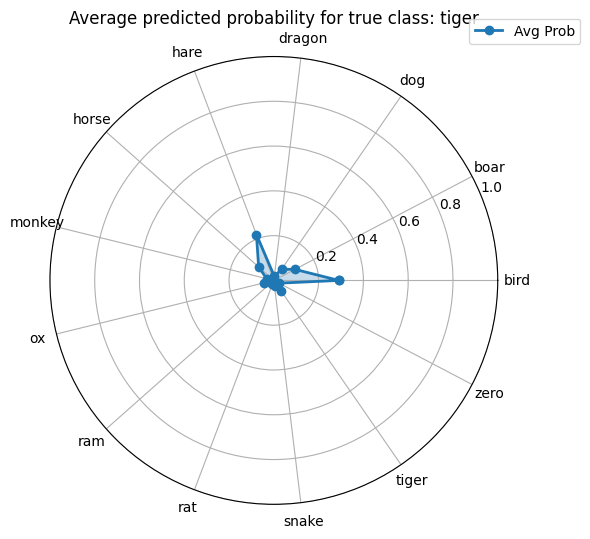

Clase 12: zero
Cantidad de imágenes: 5
Cantidad de imágenes: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


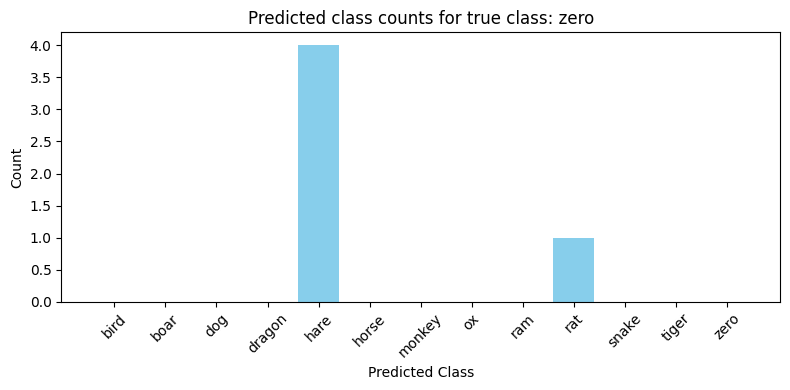

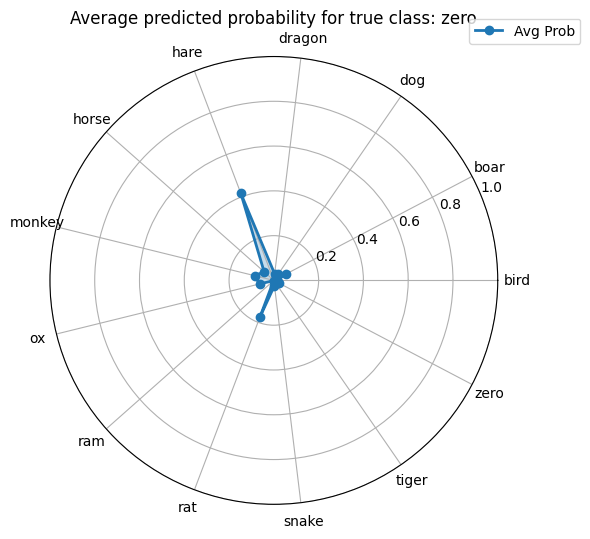

In [26]:
def filter_class(class_index):
    # Unbatch so each element is (image, label), then filter
    return second_test_dataset.unbatch().filter(lambda x, y: tf.equal(y, class_index))

def plot_predictions_radar(class_name, predictions):
    import matplotlib.pyplot as plt
    import numpy as np

    labels = class_names
    #counts = [predictions[label]['count'] for label in labels]
    #total_probs = [np.mean(predictions[label]['total_prob']) for label in labels]
    counts = []
    total_probs = []
    for label in labels:
        if label in predictions:
            counts.append(predictions[label]['count'])
            total_probs.append(np.mean(predictions[label]['total_prob']))
        else:
            counts.append(0)
            total_probs.append(0.0)

    # Plot histogram for counts
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.bar(labels, counts, color='skyblue')
    ax1.set_title(f'Predicted class counts for true class: {class_name}')
    ax1.set_ylabel('Count')
    ax1.set_xlabel('Predicted Class')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot radar/spider chart for average probabilities
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    # Complete the loop for radar
    counts_for_radar = total_probs + [total_probs[0]]
    angles += [angles[0]]

    fig, ax2 = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax2.plot(angles, counts_for_radar, 'o-', linewidth=2, label='Avg Prob')
    ax2.fill(angles, counts_for_radar, alpha=0.25)
    ax2.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax2.set_title(f'Average predicted probability for true class: {class_name}')
    ax2.set_ylim(0, 1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.tight_layout()
    plt.show()


# Iterar por las clases del conjunto de test y analizar las predicciones
for class_index, class_name in enumerate(class_names):
    # Filtrar las imágenes de la clase actual
    class_images = filter_class(class_index)
    
    print("Clase {}: {}".format(class_index, class_name))
    print("Cantidad de imágenes:", len(list(class_images)))

    df = {}

    for cname in class_names:
        df[cname] = {
            'count': 0,
            'total_prob': []
        }

    # Para cada imagen, obtener la clase predicha con mayor probabilidad
    # junto con su probabilidad
    for image, true_label in class_images:
        image = tf.expand_dims(image, axis=0)
        prediction = model.predict(image)
        
        for predicted_label, predicted_prob in enumerate(prediction[0]):
            df[class_names[predicted_label]]['total_prob'].append(predicted_prob)

        most_predicted_label = np.argmax(prediction[0])
        df[class_names[most_predicted_label]]['count'] += 1

    plot_predictions_radar(class_name, df)